# Student Performance Analysis
## Name: Chetan Kumar
## Internship: Data Science & Data Analysis with Python

In [35]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (8,5)

## Dataset Loading

In [36]:
df = pd.read_csv("student-mat.csv", sep=';')


## Dataset Overview

In [37]:
##  fist 5 row and last 5 row Look
 
print('Dataset loaded successfully!')
print(f'   Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Size  : {df.size} data points')
print('\n First 5 rows:')
df.head()

Dataset loaded successfully!
   Shape : 395 rows × 33 columns
   Size  : 13035 data points

 First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [39]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


##  shape and data types

In [40]:
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nData Types:")
print(df.dtypes)

df.head()

Shape: 395 rows × 33 columns

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Data Cleaning

In [41]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Duplicate Records:
0


##  shape and data types

In [42]:

key_cols = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3']

df[key_cols].describe().round(2)

,age,studytime,failures,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.04,0.33,5.71,10.91,10.71,10.42
std,1.28,0.84,0.74,8.00,3.32,3.76,4.58
min,15.00,1.00,0.00,0.00,3.00,0.00,0.00
25%,16.00,1.00,0.00,0.00,8.00,9.00,8.00
50%,17.00,2.00,0.00,4.00,11.00,11.00,11.00
75%,18.00,2.00,0.00,8.00,13.00,13.00,14.00
max,22.00,4.00,3.00,75.00,19.00,19.00,20.00


## Exploratory Data Analysis

In [43]:
#    Average Final Grade

avg_grade = df['G3'].mean()

print("Average Final Grade:", round(avg_grade,2))

Average Final Grade: 10.42


In [44]:
# Students Scoring Above 15
high_score = df[df['G3'] > 15]

print("Students Scoring Above 15:", len(high_score))

Students Scoring Above 15: 40


In [45]:
# Gender-wise Performance
gender_avg = df.groupby('sex')['G3'].mean()

gender_avg

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

In [46]:
#  Study Time vs Grade Correlation

correlation = df['studytime'].corr(df['G3'])

print("Correlation:", round(correlation,3))

Correlation: 0.098


##  Histogram

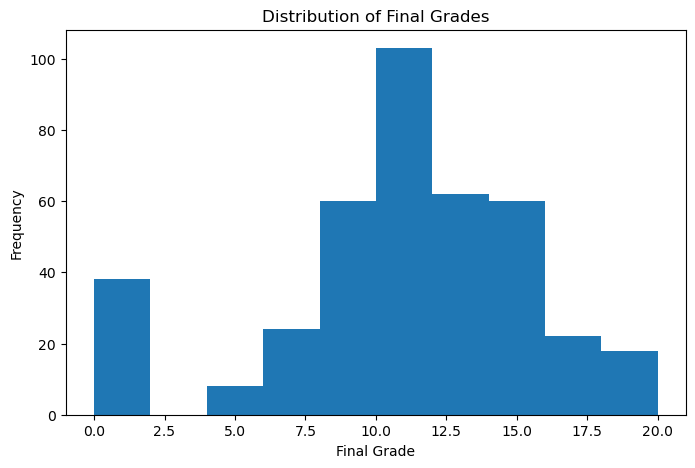

In [47]:

plt.hist(df['G3'], bins=10)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")
plt.show()

## # Scatter Plot

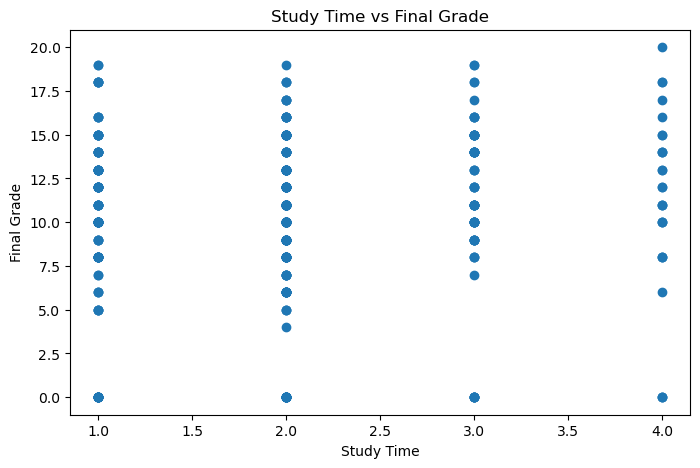

In [48]:

plt.scatter(df['studytime'], df['G3'])
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

## # Bar chart

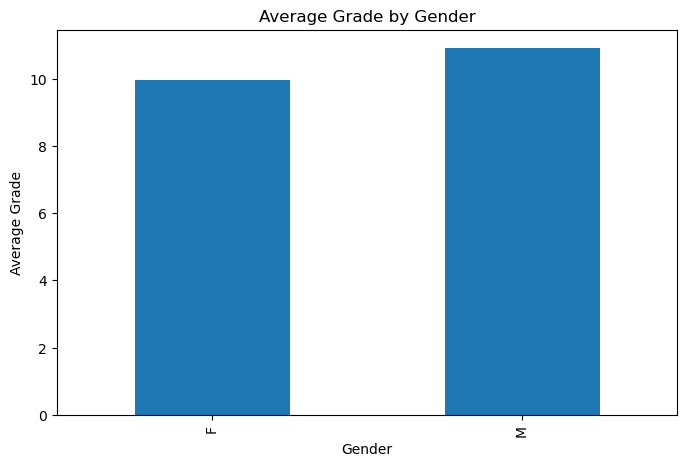

In [49]:

gender_avg.plot(kind='bar')

plt.title("Average Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grade")

plt.show()

## # Correlation Heatmap

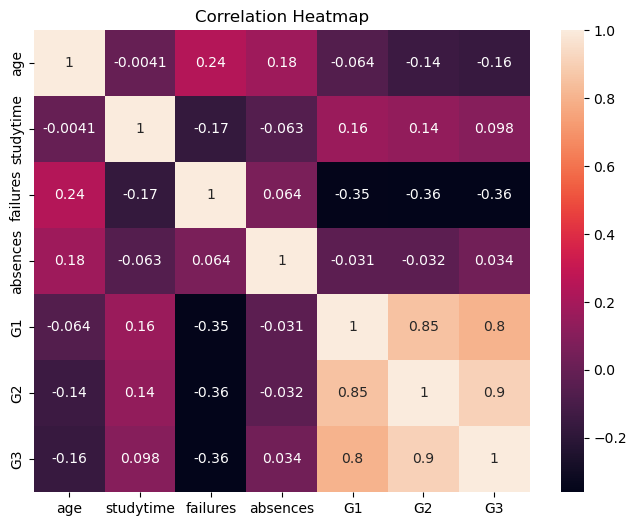

In [50]:

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['age','studytime','failures','absences','G1','G2','G3']].corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

## 5️⃣ Step 5: Conclusion & Key Insights

### 🔑 Analysis Summary

| Question | Answer |
|----------|--------|
| Average Final Grade (G3) | **10.42 / 20** |
| Students scored above 15 | **40 students (~10.1%)** |
| Study time ↔ G3 correlation | **r = 0.098** (weak positive) |
| Better performing gender | **Male** (avg 10.91 vs Female 9.97) |